#📊 Telco Customer Churn Analysis

#Objective
The objective of this project is to analyze customer churn patterns and identify the key factors contributing to customer attrition using Python and Exploratory Data Analysis.

In [25]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#display all columns
pd.set_option('display.max_columns', None)

In [27]:
#improve plot appearance
sns.set_style('whitegrid')

In [28]:
#load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.shape

(7043, 21)

In [31]:
list(df.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [32]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [35]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [36]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
#data cleaning
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [39]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [42]:
df = df.dropna()

In [43]:
#check unique value for each column
for column in df.columns:
    print(f"{column}: {df[column].unique()}")
    print("-" * 50)

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender: ['Female' 'Male']
--------------------------------------------------
SeniorCitizen: [0 1]
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
Onli

In [44]:
df.drop('customerID', axis=1, inplace=True)

In [45]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
df = df.drop_duplicates()

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.shape

(7010, 20)

In [49]:
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [50]:
df['Churn'].value_counts()

,count
Churn,
No,5153
Yes,1857


In [51]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.509272
Yes,26.490728


In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80


In [53]:
df.describe(include='object').T

,count,unique,top,freq
gender,7010,2,Male,3535
Partner,7010,2,No,3617
Dependents,7010,2,No,4911
PhoneService,7010,2,Yes,6330
MultipleLines,7010,3,No,3363
InternetService,7010,3,Fiber optic,3090
OnlineSecurity,7010,3,No,3489
OnlineBackup,7010,3,No,3079
DeviceProtection,7010,3,No,3086
TechSupport,7010,3,No,3464


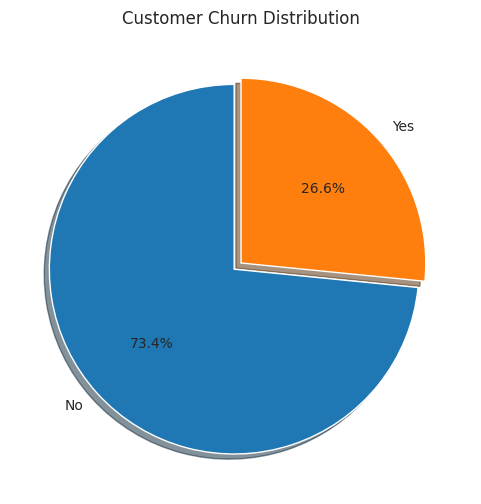

In [108]:
#exploratory data analysis

churn_labels = df['Churn'].replace({0: 'No', 1: 'Yes'}).value_counts()

plt.figure(figsize=(6,6))

churn_labels.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()

Observation: Approximately 73% of customers were retained, whereas 26% of customers churned.

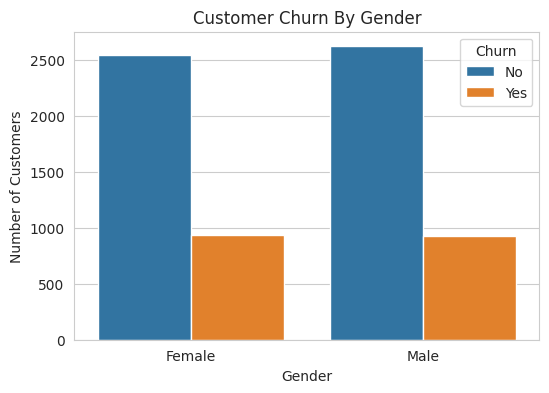

In [133]:
df_plot['Churn'] = df_plot['Churn'].replace({0: 'No', 1: 'Yes'})

plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df_plot)

plt.title("Customer Churn By Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

Observation: Male and female customers show similar churn patterns, indicating that gender is not a significant factor influencing customer churn.

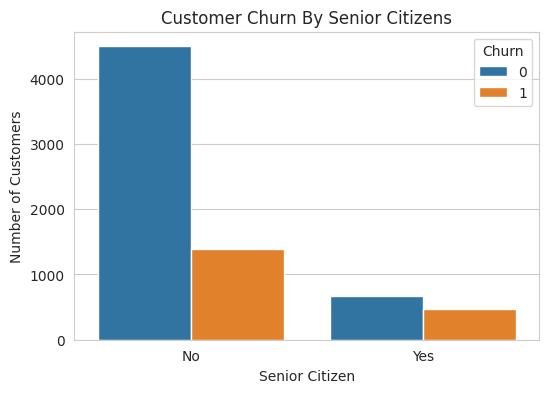

In [132]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Customer Churn By Senior Citizens")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ['No','Yes'])

plt.show()

Observation: Senior citizens have a relatively higher proportion of churn compared to non-senior customers.

In [58]:
df.shape

(7010, 20)

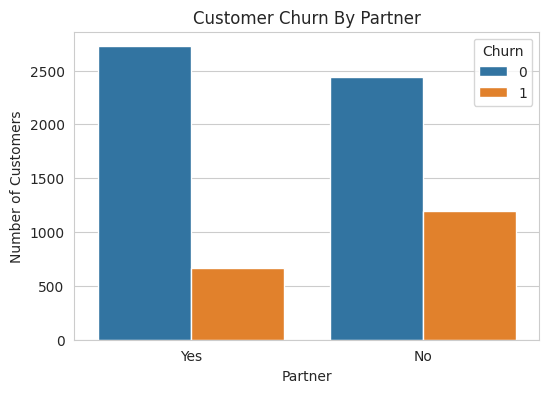

In [131]:
plt.figure(figsize=(6,4))

sns.countplot(x='Partner', hue='Churn', data=df)

plt.title("Customer Churn By Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

Observation: Customers without partners appear to churn more frequently than customers with partners.

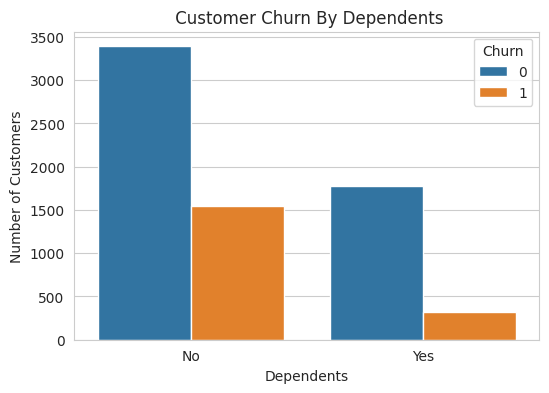

In [130]:
plt.figure(figsize=(6,4))

sns.countplot(x='Dependents', hue='Churn', data=df)

plt.title(" Customer Churn By Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

Observation: Customers without dependents have a higher churn rate than those with dependents.

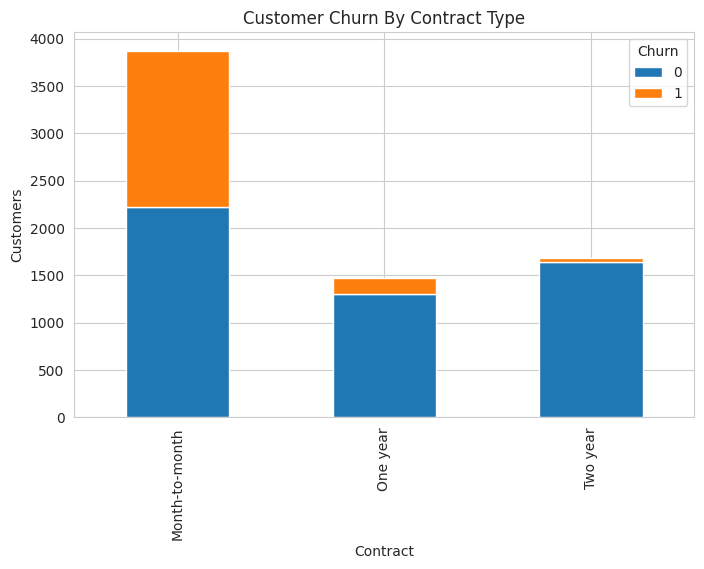

In [134]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn By Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.show()

Insight: Customers on month-to-month contracts show the highest churn. This suggests that long-term contracts improve customer retention and should be encouraged through incentives or loyalty programs.

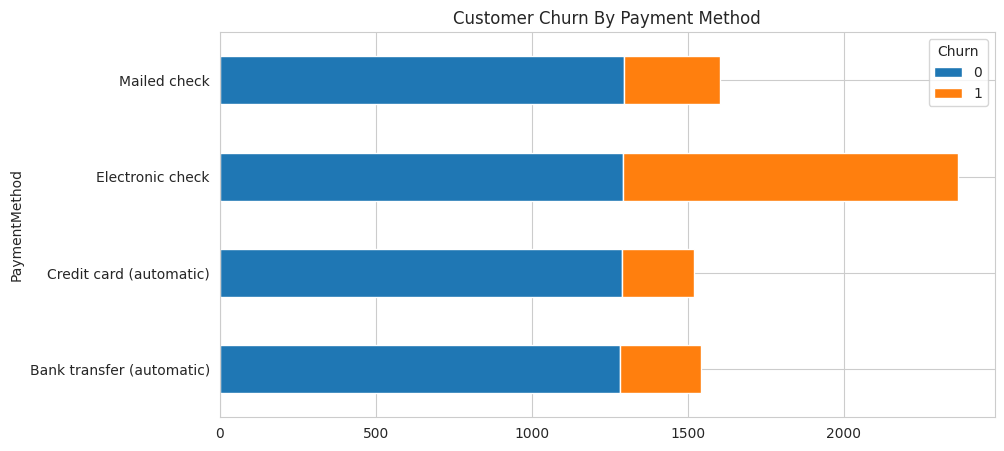

In [135]:
payment = pd.crosstab(df['PaymentMethod'],df['Churn'])

payment.plot(
    kind='barh',
    stacked=True,
    figsize=(10,5)
)

plt.title("Customer Churn By Payment Method")
plt.show()

Observation: Customers using Electronic Check have the highest churn compared to other payment methods.

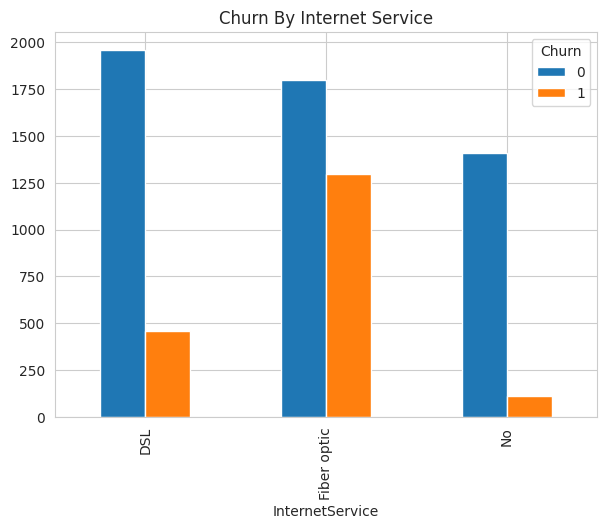

In [136]:
internet = pd.crosstab(df['InternetService'],df['Churn'])

internet.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Churn By Internet Service")
plt.show()

Observation: Customers using Fiber Optic internet have the highest churn compared to customers using DSL or those without internet service.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

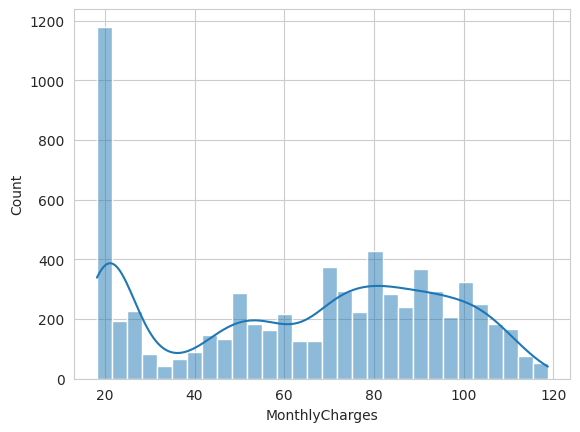

In [118]:
sns.histplot(df['MonthlyCharges'],
             bins=30,
             kde=True)

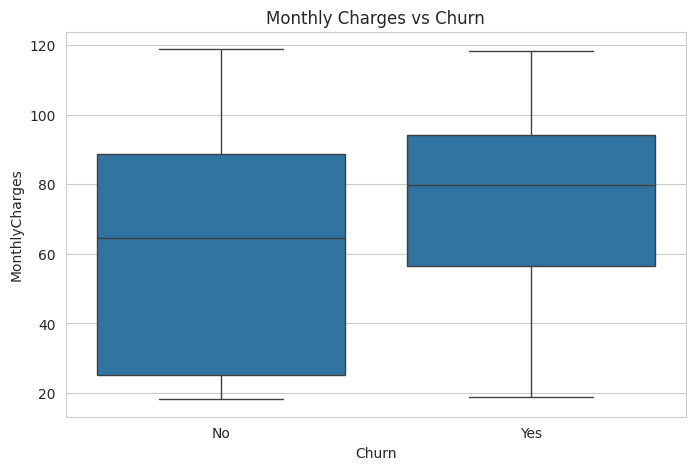

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

Insight: Higher monthly charges may increase the likelihood of customer churn. The company can reduce churn by offering personalized pricing, discounts, or value-added benefits to customers with higher monthly bills.

<Axes: xlabel='tenure', ylabel='Count'>

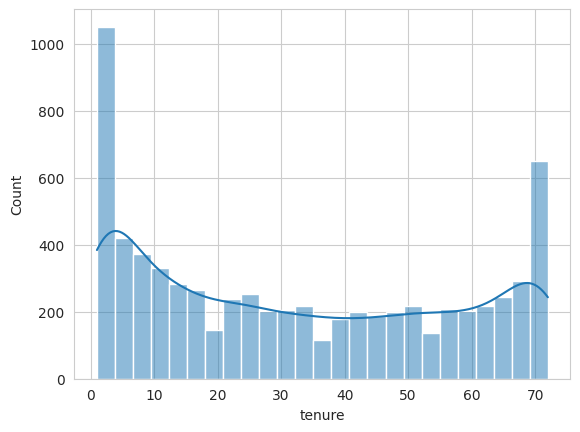

In [119]:
sns.histplot(df['tenure'],
             bins=25,
             kde=True)

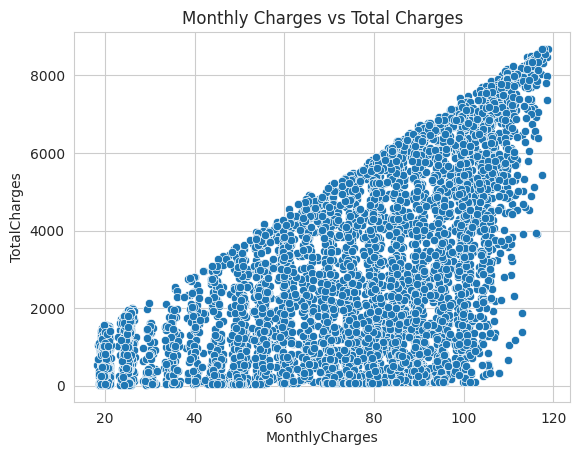

In [120]:
sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    data=df
)

plt.title("Monthly Charges vs Total Charges")
plt.show()

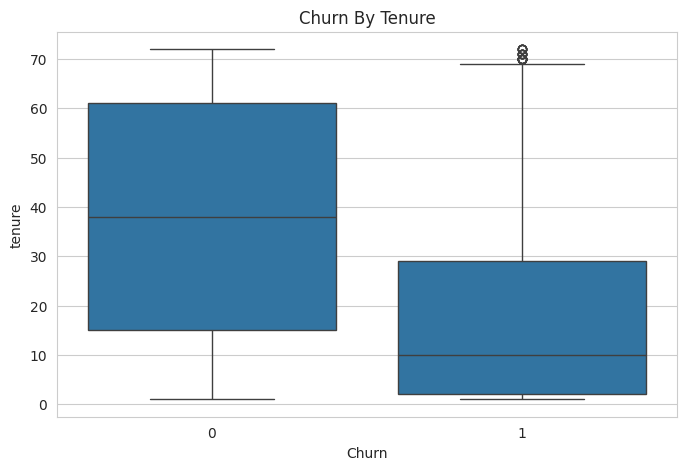

In [137]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Churn By Tenure")

plt.show()

Insight: The risk of churn is highest during the early months of a customer's subscription. The company should focus on onboarding programs, welcome offers, and early engagement strategies to improve customer retention.

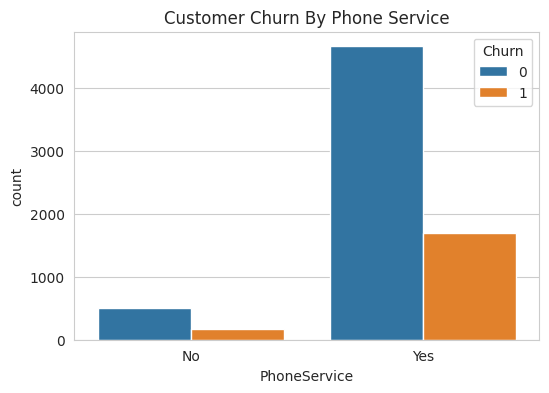

In [140]:
plt.figure(figsize=(6,4))
sns.countplot(x='PhoneService', hue='Churn', data=df)

plt.title("Customer Churn By Phone Service")
plt.show()

Observation: Phone service does not show a significant difference in churn behavior.

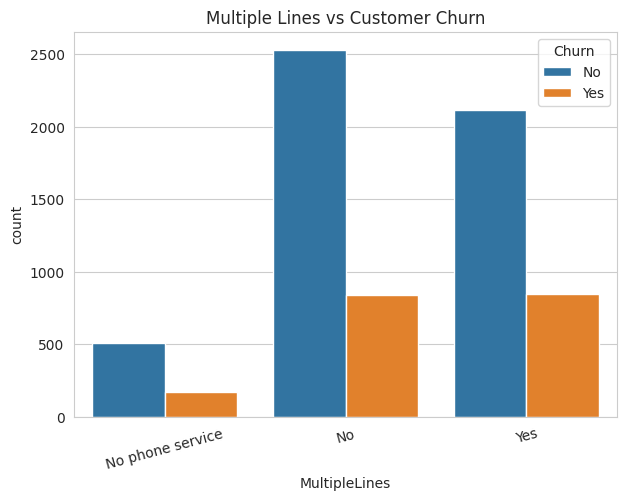

In [69]:
plt.figure(figsize=(7,5))
sns.countplot(x='MultipleLines', hue='Churn', data=df)

plt.title("Customer Churn By Multiple Lines")
plt.xticks(rotation=15)
plt.show()

Observation: Customers with multiple lines exhibit a slightly higher churn rate, but the difference is not substantial.

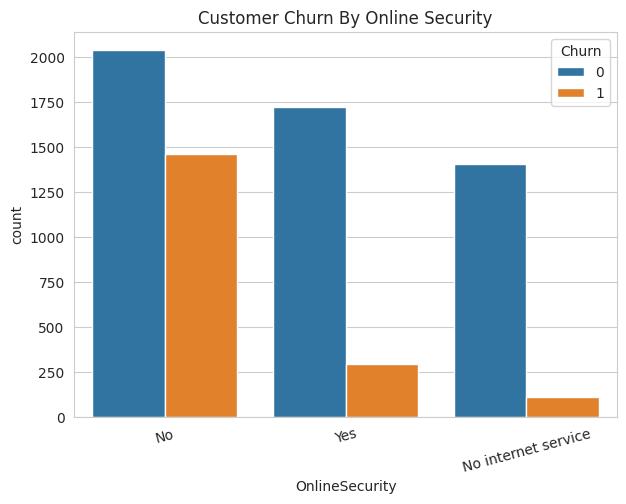

In [141]:
plt.figure(figsize=(7,5))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)

plt.title("Customer Churn By Online Security")
plt.xticks(rotation=15)
plt.show()

Insight: value-added services such as online security increase customer loyalty. Promoting security packages and bundled plans may reduce churn.

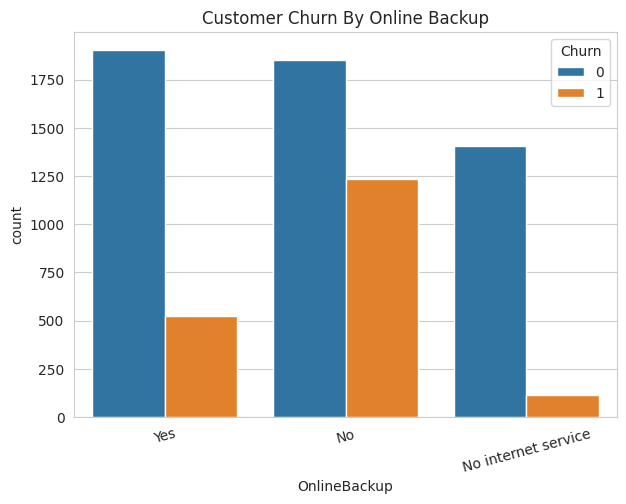

In [142]:
plt.figure(figsize=(7,5))
sns.countplot(x='OnlineBackup', hue='Churn', data=df)

plt.title("Customer Churn By Online Backup")
plt.xticks(rotation=15)
plt.show()

Observation: Customers without online backup tend to churn more than those who subscribe to the service.

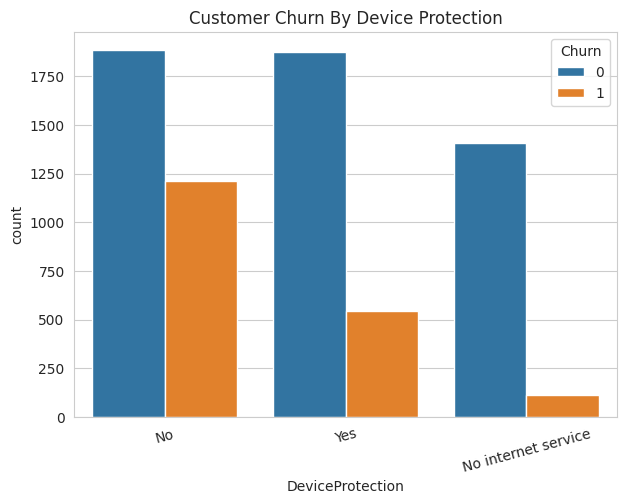

In [143]:
plt.figure(figsize=(7,5))
sns.countplot(x='DeviceProtection', hue='Churn', data=df)

plt.title("Customer Churn By Device Protection")
plt.xticks(rotation=15)
plt.show()

Observation: Customers with device protection appear to have better retention than those without it.

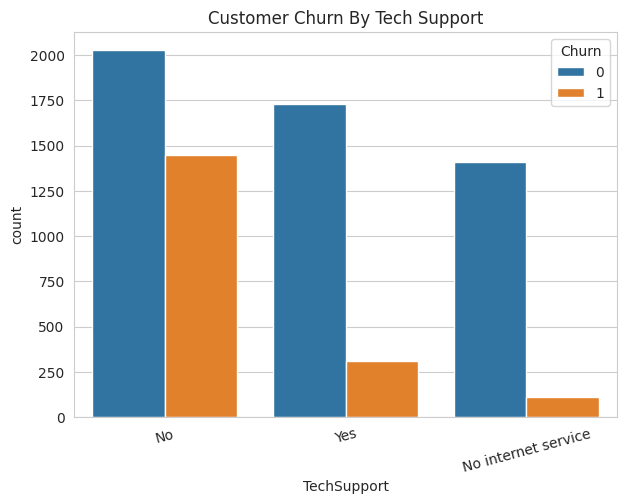

In [144]:
plt.figure(figsize=(7,5))
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.title("Customer Churn By Tech Support")
plt.xticks(rotation=15)
plt.show()

Insight: Reliable customer support plays a significant role in customer retention. The company should encourage customers to subscribe to technical support services and continuously improve service quality.

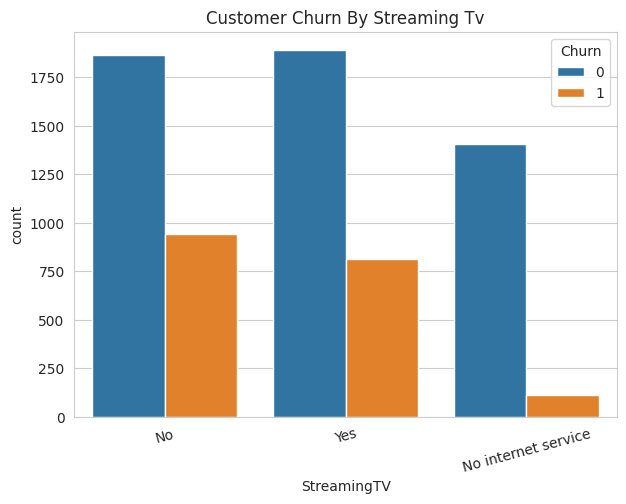

In [145]:
plt.figure(figsize=(7,5))
sns.countplot(x='StreamingTV', hue='Churn', data=df)

plt.title("Customer Churn By Streaming Tv")
plt.xticks(rotation=15)
plt.show()

Observation: Streaming TV services show only a minor difference in customer churn.

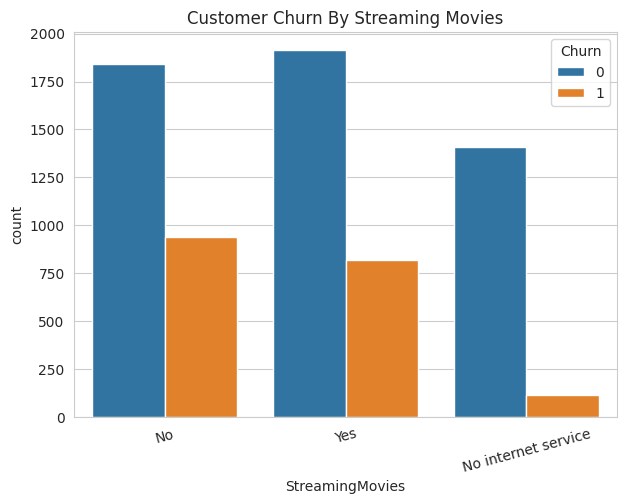

In [146]:
plt.figure(figsize=(7,5))
sns.countplot(x='StreamingMovies', hue='Churn', data=df)

plt.title("Customer Churn By Streaming Movies")
plt.xticks(rotation=15)
plt.show()

Observation: Streaming Movies has a limited impact on customer churn compared to factors such as contract type and tenure.

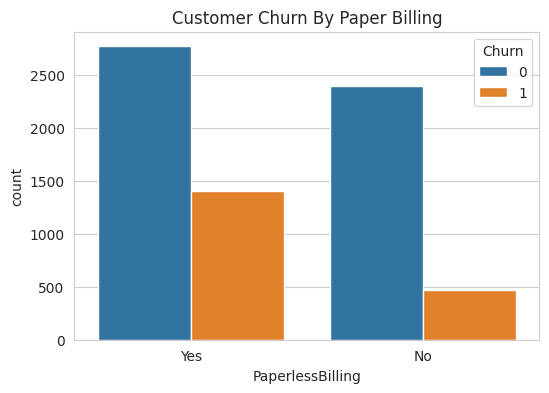

In [147]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)

plt.title("Customer Churn By Paper Billing")
plt.show()

Observation: Customers using paperless billing show a relatively higher churn rate than those using traditional billing.

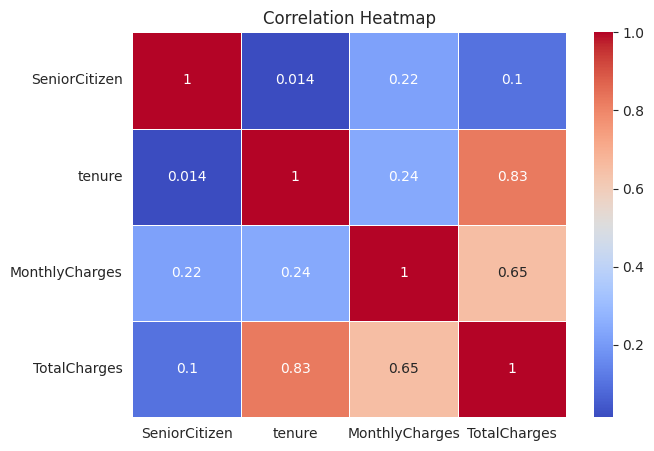

In [78]:
plt.figure(figsize=(7,5))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Observation: Total Charges is strongly positively correlated with Tenure, indicating that customers who stay longer contribute more revenue. Other numerical variables show relatively weak correlations, suggesting churn depends on multiple factors.

#Business Recommendations

1. Introduce attractive discounts to encourage customers to switch from month-to-month to annual contracts.
2. Develop targeted retention campaigns for customers with high monthly charges.
3. Strengthen onboarding and engagement programs for new customers to reduce early churn.
4. Improve the quality and customer experience of Fiber Optic internet services.
5. Encourage automatic payment methods by providing incentives or cashback offers.
6. Bundle online security and technical support services with internet plans to increase customer satisfaction and loyalty.


# Conclusion

The analysis identified several important factors influencing customer churn. Customers on month-to-month contracts, those with higher monthly charges, shorter tenure, and without value-added services such as online security and technical support were more likely to leave the company. By improving customer engagement, promoting long-term contracts, and enhancing service offerings, the company can significantly reduce churn and improve customer retention.